In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("outputs/figures", exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"outputs/figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Load the dataset**

In [9]:
df = pd.read_csv("/content/wholesale.csv")

SPEND = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
print(df.shape)
display(df.head())
display(df.describe().T)
print("Missing values:", int(df.isna().sum().sum()), "| Duplicate rows:", int(df.duplicated().sum()))

(440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


Missing values: 0 | Duplicate rows: 0


## **Exploratory data analysis**
Spend data is typically **right-skewed with heavy outliers** (a few very large buyers). Distance-based methods like K-Means are sensitive to this, so we check skewness before deciding on transformations.

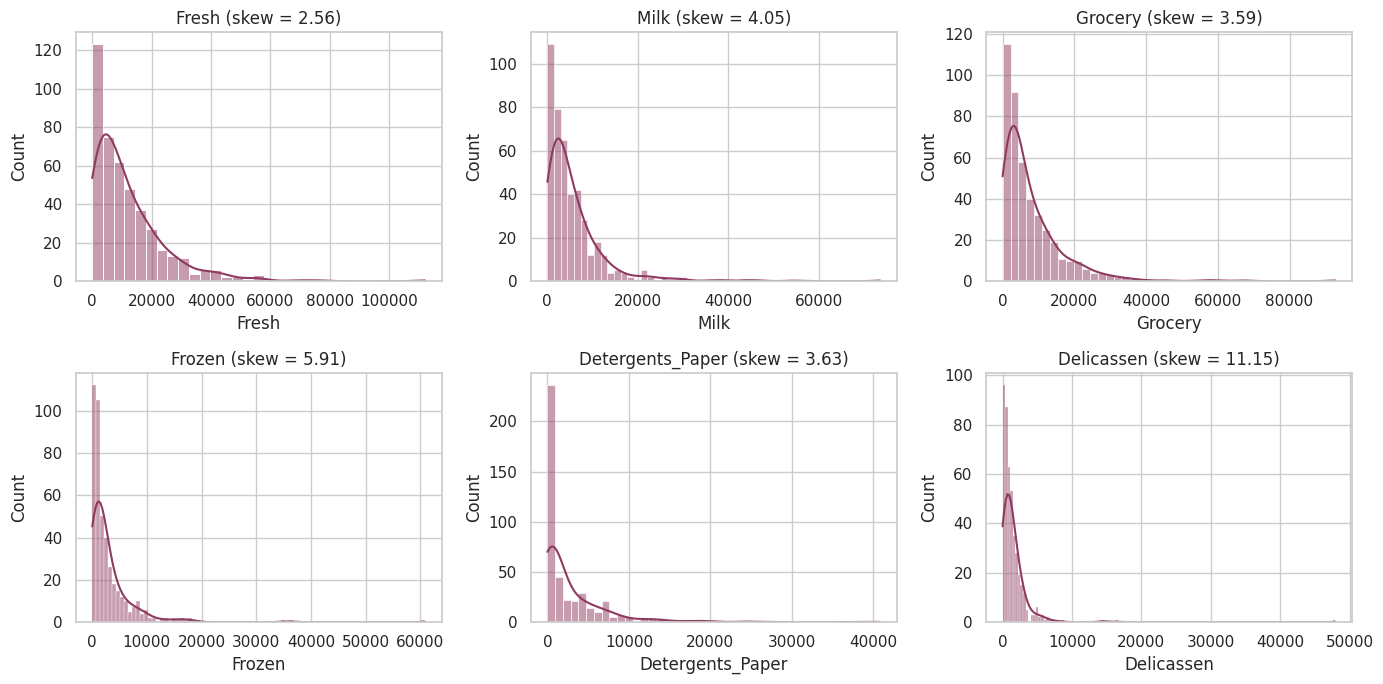

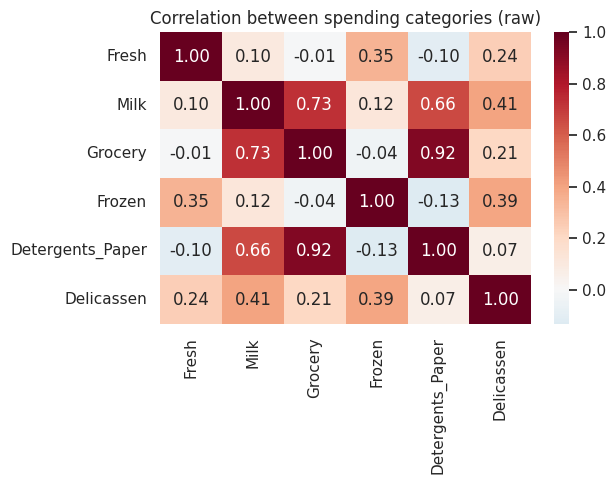

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), SPEND):
    sns.histplot(df[c], kde=True, ax=ax, color="#8E3B5F")
    ax.set_title(f"{c} (skew = {df[c].skew():.2f})")
save_fig("01_raw_distributions")

plt.figure(figsize=(6.5, 5))
sns.heatmap(df[SPEND].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation between spending categories (raw)")
save_fig("02_correlation_raw")

##**Preprocessing: log transform and standardisation**

`log1p` compresses the long right tail; `StandardScaler` puts every category on the same scale so no single category dominates the distance calculation.

In [11]:
X_log = np.log1p(df[SPEND])
print(pd.DataFrame({"skew_before": df[SPEND].skew(), "skew_after_log": X_log.skew()}).round(2))

scaler = StandardScaler()
X = scaler.fit_transform(X_log)

# Outliers are flagged (|z| > 3 on any feature) but KEPT: big buyers are real customers a business wants to see.
outlier_mask = (np.abs(X) > 3).any(axis=1)
print(f"Customers with an extreme value on at least one category: {outlier_mask.sum()} ({outlier_mask.mean():.1%})")

                  skew_before  skew_after_log
Fresh                    2.56           -1.58
Milk                     4.05           -0.22
Grocery                  3.59           -0.67
Frozen                   5.91           -0.35
Detergents_Paper         3.63           -0.24
Delicassen              11.15           -1.09
Customers with an extreme value on at least one category: 18 (4.1%)


##**Principal Component Analysis (PCA)**
PCA reveals the main spending dimensions .

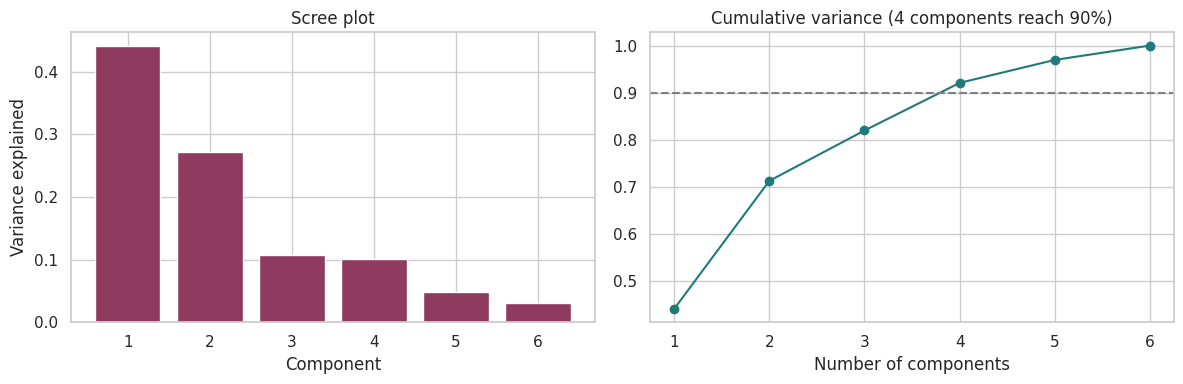

                   PC1   PC2
Fresh            -0.11  0.59
Milk              0.54  0.13
Grocery           0.57 -0.01
Frozen           -0.14  0.59
Detergents_Paper  0.55 -0.07
Delicassen        0.21  0.53

PC1 + PC2 explain 71.3% of the variance


In [12]:
pca_full = PCA(random_state=SEED).fit(X)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_90 = int(np.argmax(cum >= 0.90) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(evr) + 1), evr, color="#8E3B5F"); ax[0].set_title("Scree plot")
ax[0].set_xlabel("Component"); ax[0].set_ylabel("Variance explained")
ax[1].plot(range(1, len(cum) + 1), cum, marker="o", color="#1F7A7A"); ax[1].axhline(0.90, ls="--", c="grey")
ax[1].set_title(f"Cumulative variance ({n_90} components reach 90%)"); ax[1].set_xlabel("Number of components")
save_fig("03_pca_variance")

loadings = pd.DataFrame(pca_full.components_[:2].T, index=SPEND, columns=["PC1", "PC2"])
print(loadings.round(2))
print(f"\nPC1 + PC2 explain {cum[1]:.1%} of the variance")

pca2 = PCA(n_components=2, random_state=SEED)
Z2 = pca2.fit_transform(X)


##**K-Means: choosing the number of clusters**
We combine four:
* **Elbow (inertia)** - where adding clusters stops paying off
* **Silhouette** - higher is better (cohesion vs separation)
* **Calinski-Harabasz** - higher is better
* **Davies-Bouldin** - lower is better

,inertia,silhouette,calinski_harabasz,davies_bouldin
k,,,,
2,1844.064,0.290,189.050,1.352
3,1553.413,0.258,152.837,1.348
4,1386.863,0.188,131.320,1.541
5,1266.149,0.192,118.000,1.484
6,1174.536,0.195,108.300,1.414
7,1086.359,0.196,103.208,1.392
8,1024.047,0.191,97.386,1.385
9,973.141,0.197,92.281,1.383
10,931.998,0.191,87.559,1.344


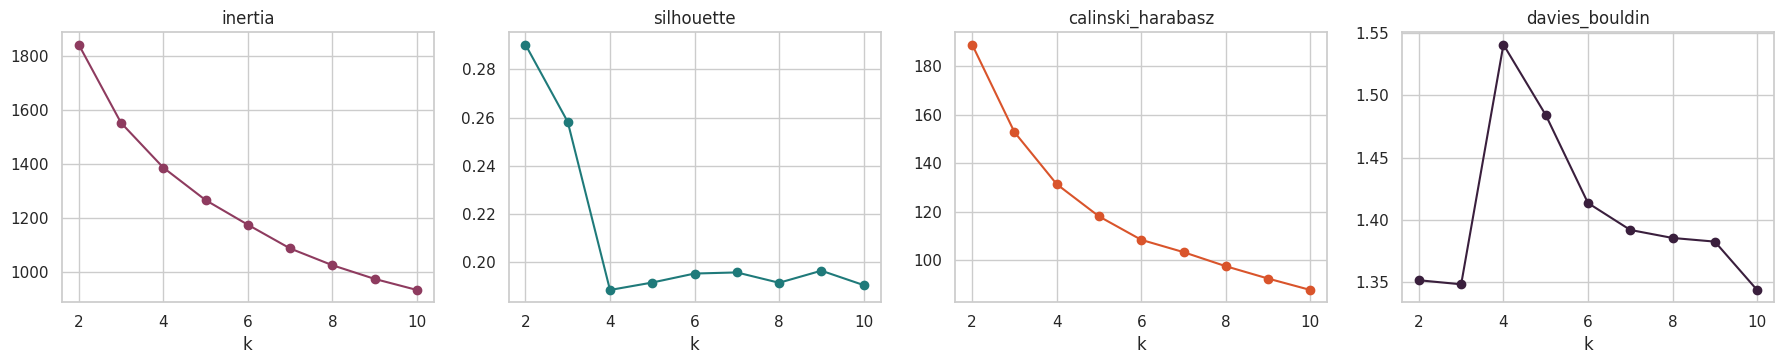

k with the best silhouette: 2


In [13]:
rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(X)
    rows.append(dict(k=k, inertia=km.inertia_,
                     silhouette=silhouette_score(X, km.labels_),
                     calinski_harabasz=calinski_harabasz_score(X, km.labels_),
                     davies_bouldin=davies_bouldin_score(X, km.labels_)))
scores = pd.DataFrame(rows).set_index("k")
display(scores.round(3))

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col, c in zip(axes, scores.columns, ["#8E3B5F", "#1F7A7A", "#D9542B", "#3A1F3D"]):
    ax.plot(scores.index, scores[col], marker="o", color=c); ax.set_title(col); ax.set_xlabel("k")
save_fig("04_kmeans_selection")

best_k = int(scores["silhouette"].idxmax())
print("k with the best silhouette:", best_k)

In [14]:
K = best_k
print("Using K =", K)

km = KMeans(n_clusters=K, n_init=50, random_state=SEED).fit(X)
labels_km = km.labels_

Using K = 2


- K = 2 was best on silhouette (0.290)
- Calinski-Harabasz (189.05, which falls steadily as K rises).
- Davies-Bouldin is almost flat (1.35 at K = 2 and 1.35 at K = 3), so it neither supports nor contradicts K = 2.
- Inertia fell smoothly with no sharp elbow, so K = 2 is the best-supported choice but not an overwhelming one.

## **Hierarchical clustering**
We compare linkage methods with the **cophenetic correlation** (how faithfully the dendrogram preserves the original pairwise distances), then cut the Ward tree at the same K.

Cophenetic correlation: {'ward': np.float64(0.484), 'complete': np.float64(0.654), 'average': np.float64(0.745)}


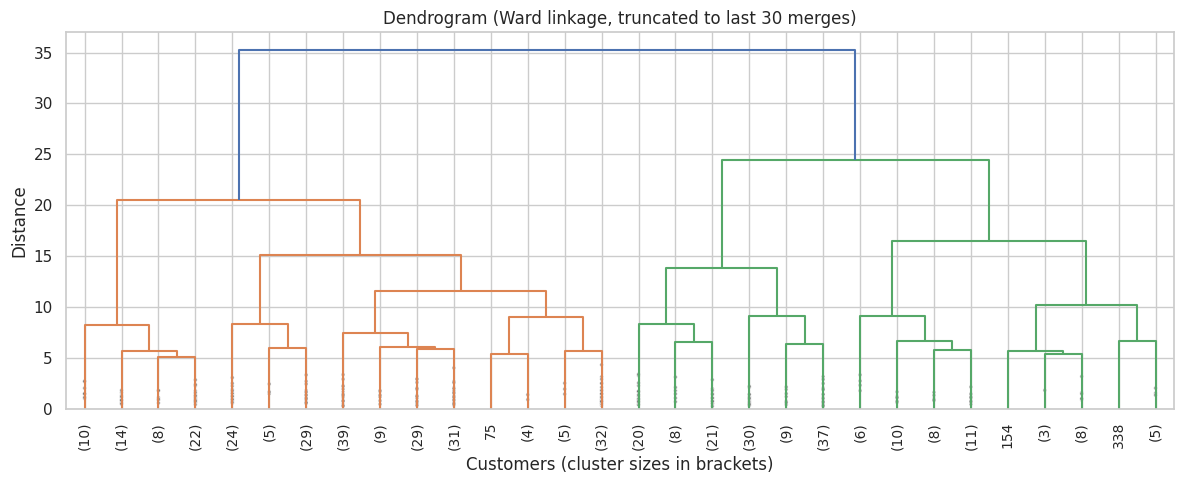

In [15]:
dist = pdist(X)
coph = {}
for method in ["ward", "complete", "average"]:
    Zm = linkage(X, method=method)
    coph[method] = cophenet(Zm, dist)[0]
print("Cophenetic correlation:", {m: round(v, 3) for m, v in coph.items()})

Z = linkage(X, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, show_contracted=True, color_threshold=Z[-(K - 1), 2])
plt.title("Dendrogram (Ward linkage, truncated to last 30 merges)"); plt.xlabel("Customers (cluster sizes in brackets)"); plt.ylabel("Distance")
save_fig("05_dendrogram")

labels_hc = fcluster(Z, t=K, criterion="maxclust") - 1

,K-Means,Hierarchical (Ward)
Silhouette,0.290,0.258
Calinski-Harabasz,189.050,134.624
Davies-Bouldin,1.352,1.600


Agreement between K-Means and Hierarchical (Adjusted Rand Index): 0.639
Stability over 50 subsamples (mean ARI): 0.967 +/- 0.038


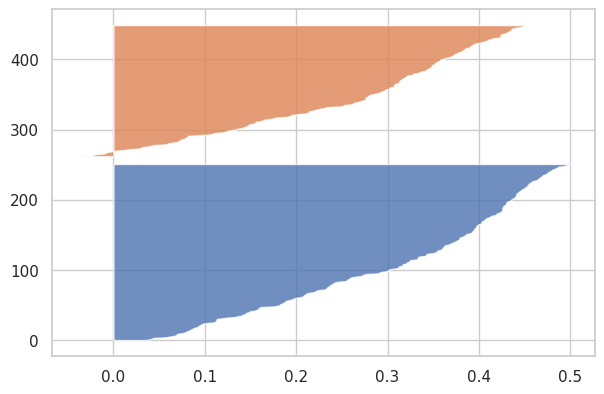

In [16]:
summary = pd.DataFrame({
    "K-Means": [silhouette_score(X, labels_km), calinski_harabasz_score(X, labels_km), davies_bouldin_score(X, labels_km)],
    "Hierarchical (Ward)": [silhouette_score(X, labels_hc), calinski_harabasz_score(X, labels_hc), davies_bouldin_score(X, labels_hc)],
}, index=["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]).round(3)
display(summary)

ari_methods = adjusted_rand_score(labels_km, labels_hc)
print(f"Agreement between K-Means and Hierarchical (Adjusted Rand Index): {ari_methods:.3f}")

# Stability: re-run K-Means on 80% bootstrap-style subsamples and compare with the full-data solution
rng = np.random.default_rng(SEED)
aris = []
for _ in range(50):
    idx = rng.choice(len(X), size=int(0.8 * len(X)), replace=False)
    sub = KMeans(n_clusters=K, n_init=10, random_state=int(rng.integers(1e6))).fit(X[idx])
    aris.append(adjusted_rand_score(labels_km[idx], sub.labels_))
print(f"Stability over 50 subsamples (mean ARI): {np.mean(aris):.3f} +/- {np.std(aris):.3f}")

# Per-customer silhouette
sil = silhouette_samples(X, labels_km)
plt.figure(figsize=(7, 4.5))
y0 = 0
for c in range(K):
    s = np.sort(sil[labels_km == c]); plt.fill_betweenx(np.arange(y0, y0 + len(s)), 0, s, alpha=0.8, label=f"Cluster {c}"); y0 += len(s) + 10

## **Visualise segments in PCA space**

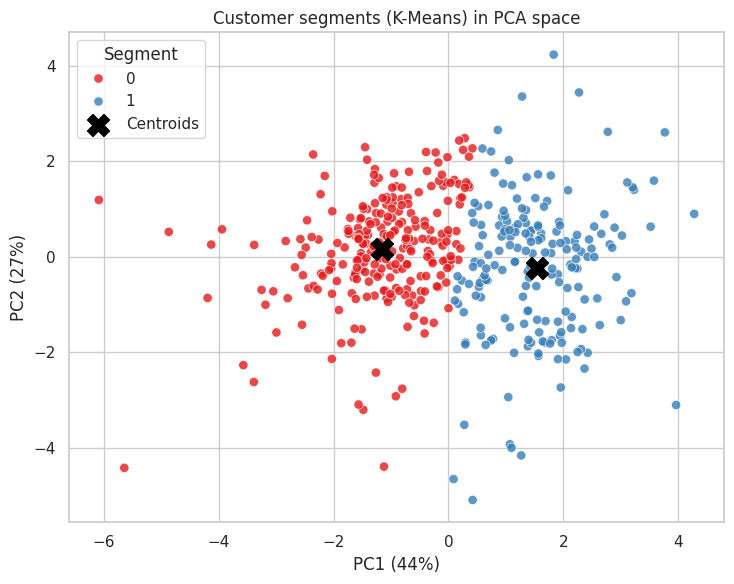

In [17]:
plt.figure(figsize=(7.5, 6))
sns.scatterplot(x=Z2[:, 0], y=Z2[:, 1], hue=labels_km, palette="Set1", s=45, alpha=0.8)
cent = pca2.transform(km.cluster_centers_)
plt.scatter(cent[:, 0], cent[:, 1], c="black", marker="X", s=250, label="Centroids")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.0%})"); plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.0%})")
plt.title("Customer segments (K-Means) in PCA space"); plt.legend(title="Segment")
save_fig("07_clusters_pca")

,customers,% of customers,% of total spend
Segment,,,
0,252,0.573,0.423
1,188,0.427,0.577


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Segment,,,,,,
0,10347.5,1871.0,2406.0,2225.0,327.5,749.5
1,5406.5,7690.5,11527.0,1061.5,4495.0,1388.5


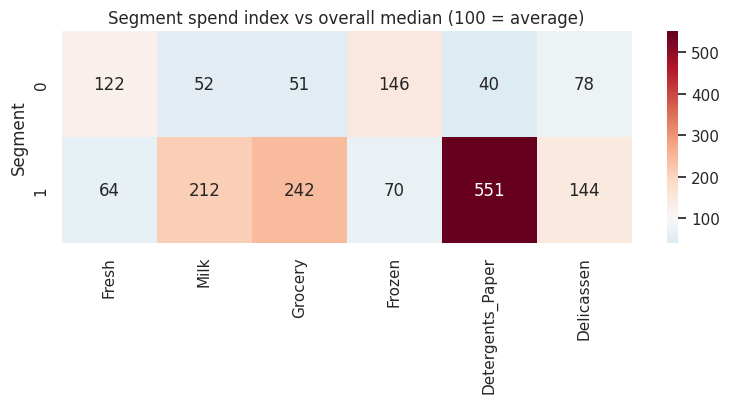

{0: 'Segment 0: Frozen + Fresh heavy', 1: 'Segment 1: Detergents_Paper + Grocery heavy'}

Channel (1 = Horeca, 2 = Retail) by segment:


Channel,1,2
Segment,,
0,0.97,0.03
1,0.29,0.71


Region by segment:


Region,1,2,3
Segment,,,
0,0.19,0.11,0.70
1,0.15,0.10,0.74


In [18]:
df["Segment"] = labels_km
profile = df.groupby("Segment")[SPEND].median()
index_tbl = (profile / df[SPEND].median() * 100).round(0)
size = df["Segment"].value_counts().sort_index()
spend_share = df.groupby("Segment")[SPEND].sum().sum(axis=1) / df[SPEND].sum().sum()

display(pd.concat([size.rename("customers"), (size / len(df)).rename("% of customers").round(3),
                   spend_share.rename("% of total spend").round(3)], axis=1))
display(profile)

plt.figure(figsize=(8, 3 + 0.6 * K))
sns.heatmap(index_tbl, annot=True, fmt=".0f", cmap="RdBu_r", center=100)
plt.title("Segment spend index vs overall median (100 = average)")
save_fig("08_segment_index_heatmap")

# Auto-generate a descriptive name from each segment's two strongest categories
names = {}
for s in index_tbl.index:
    top = index_tbl.loc[s].sort_values(ascending=False).head(2).index.tolist()
    names[s] = f"Segment {s}: {top[0]} + {top[1]} heavy"
print(names)

# Cross-check against the labels we did NOT use for clustering
print("\nChannel (1 = Horeca, 2 = Retail) by segment:")
display(pd.crosstab(df["Segment"], df["Channel"], normalize="index").round(2))
print("Region by segment:")
display(pd.crosstab(df["Segment"], df["Region"], normalize="index").round(2))

## **Business interpretation**

**Segment 0**: fresh and frozen buyers (hotel, restaurant and café type)

- It is the larger group (57% of customers) but the smaller revenue contributor (42%).
- It buys perishables heavily and under-buys milk, grocery and especially detergents and paper.


**Suggested actions**:
- Prioritise delivery frequency, cold-chain reliability and freshness guarantees.
- Offer fresh and frozen bundles.

**Segment 1**: high-volume grocery and household buyers (retail type)

- It is the smaller group (43% of customers) but produces 58% of revenue, at about 1.8 times the average spend per customer.

**Suggested actions**:
- Offer volume or contract pricing and loyalty terms.
- Guarantee stock availability on grocery, dairy and cleaning lines.
- Run account management for retention, because revenue depends on fewer customers.